<a href="https://colab.research.google.com/github/one-2730/ESAA-24-2/blob/Session/ESAA_YB_1115_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 규제 선형 회귀 모델/ 회귀 트리**
- 릿지 회귀모델 및 회귀 트리를 이용하여 전복의 나이를 예측해 보세요.

- 전복의 ‘성별’, ‘키’, ‘지름’, ‘높이’, ‘전체무게’, ‘몸통무게’, ‘내장무게’, ‘껍질무게’를 이용해 ‘껍질의 고리수’를 예측한 뒤, **예측된 ‘껍질의 고리수’에 1.5를 더하면 전복의 나이**가 됩니다.

In [1]:
# 기본 모듈 불러오기
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

### 1) 데이터 불러오기 및 데이터 선택

In [2]:
# 데이터 로드
data = pd.read_csv("abalone.csv")

# 성별 M은 Male, F는 Female, I는 Infant 이므로 따로 열 만들기
for label in "MFI":
    data[label] = data["Sex"] == label
data.drop('Sex', axis=1, inplace=True)

# X,y 데이터 선택
y = data.Rings.values
data.drop('Rings', axis=1, inplace=True)

X = data.values.astype(float)

## 2) train/test 분리
: 테스트 셋과 데이터 셋을 7:3 비율로 분리하세요.

In [3]:
# 필요한 모듈 불러오기
from sklearn.model_selection import train_test_split

In [4]:
# train과 test set 분리 (train:test = 7:3 비율로)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

## 3) 릿지 모델을 이용한 모델링
: 릿지 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

 3-1) 릿지모델 생성, 교차검증, 평가에 필요한 모듈을 불러오세요.

In [5]:
#필요한 모듈 불러오기

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error

3-2) 릿지 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요. 릿지 모델 생성 시  alpha는 0.3으로 설정합니다. (교차 검증 하지 않습니다.)

In [6]:
#릿지모델 생성 및 훈련
ridge = Ridge(alpha = 0.3)
ridge.fit(X_train, y_train)

#예측값 구하기
ridge_pred = ridge.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
pred_age = ridge_pred + 1.5

#MSE와 RMSE구하기
ridge_MSE = mean_squared_error(y_test, ridge_pred)
ridge_RMSE = np.sqrt(ridge_MSE)

print(ridge_MSE, ridge_RMSE)

4.7136382328032855 2.171091484208642


3-3) 교차검증을 이용하여 0, 0.1, 1, 10, 100 중  모델 성능이 가장 좋게 나오는 (rmse가 최소가 되는) alpha를 구하세요.

In [7]:
# 주어진 alpha
alphas=[0, 0.1, 1, 10, 100]
params = {'alpha' : alphas}

ridge = Ridge()

def print_best_params(model, params):
  grid_model = GridSearchCV(model, param_grid = params, scoring = 'neg_mean_squared_error', cv = 5)
  grid_model.fit(X_train, y_train)
  rmse = np.sqrt(-1*grid_model.best_score_)
  print('{0} 5 CV 시 최적 평균 RMSE 값: {1}, 최적 alpha: {2}'.format(model.__class__.__name__, np.round(rmse, 4), grid_model.best_params_))

print_best_params(ridge, params)

Ridge 5 CV 시 최적 평균 RMSE 값: 2.2144, 최적 alpha: {'alpha': 0.1}


In [8]:
#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
#cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
for alpha in alphas:
  ridge = Ridge(alpha = alpha)
  cv_error = cross_val_score(ridge, X, y, scoring = 'neg_mean_squared_error', cv = 5)
  mean_rmse = np.mean(np.sqrt(-1 * cv_error))
  print('alpha: {0}, rmse: {1}'.format(alpha, mean_rmse))

alpha: 0, rmse: 2.244092816449407
alpha: 0.1, rmse: 2.237136825983052
alpha: 1, rmse: 2.230321200422366
alpha: 10, rmse: 2.337280509131002
alpha: 100, rmse: 2.621188059927813


## 4) XGBRegressor을 이용한 모델링
: XGBRegressor 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

4-1) XGBRegressor 훈련, 평가에 필요한 모듈을 불러오세요.

In [9]:
# 필요한 모듈 임포트
from xgboost import XGBRegressor
from sklearn import metrics

4-2) XGBregressor 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요.

In [10]:
#모델 생성 및 훈련
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

#예측값 구하기
pred = xgb.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
pred_age = pred + 1.5

#MSE와 RMSE 구하기
xgb_MSE = mean_squared_error(y_test, ridge_pred)
xgb_RMSE = np.sqrt(ridge_MSE)

4-3) 생성한 모델의 피처 중요도를 시각화해보세요.

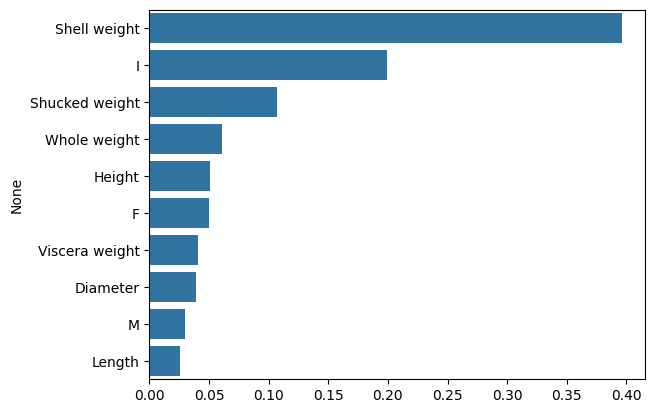

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
importance = pd.Series(xgb.feature_importances_, index = data.columns).sort_values(ascending = False)
sns.barplot(x = importance.values, y = importance.index)
plt.show()

# **2. 로지스틱 회귀분석**
load_wine() 함수를 이용하여 와인 데이터를 다항분류하는 로지스틱 회귀모델을 생성하세요.

In [12]:
# 필요한 모듈 불러오기
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1) 데이터 불러오기 및 변수 선택

In [13]:
wine = load_wine()

wine_x = wine.data # x변수
wine_y = wine.target # y변수

## 2) train/test 셋 분리

In [14]:
x_train, x_test, y_train, y_test = train_test_split(wine_x, wine_y, test_size=0.3, random_state=123)

print(x_train.shape, y_train.shape)

(124, 13) (124,)


## 3) 로지스틱 회귀모델을 이용한 모델링

3-1) 로지스틱 회귀모델을 생성하여 훈련하세요.

In [15]:
from sklearn.linear_model import LogisticRegression

logit_reg = LogisticRegression()
logit_reg.fit(x_train, y_train)

LogisticRegression()

3-2) 회귀 모델의 기울기와 절편을 구하세요.

In [16]:
#기울기
coef = pd.DataFrame(logit_reg.coef_)
coef

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.199751,0.365451,0.149472,-0.188027,-0.022849,0.195457,0.466702,-0.016680,0.082390,0.067501,-0.019262,0.294916,0.007425
1,0.596477,-0.788674,-0.126182,0.212254,-0.011350,0.315787,0.355149,0.033468,0.279036,-1.172027,0.261166,0.464732,-0.008336
2,-0.396725,0.423223,-0.023291,-0.024227,0.034200,-0.511243,-0.821851,-0.016788,-0.361426,1.104526,-0.241904,-0.759649,0.000911


In [17]:
#절편
logit_reg.intercept_

array([-0.04177844,  0.09551062, -0.05373218])

3-3) 모델의 정확도를 구하세요.

In [18]:
#모델의 예측값 구하기
pred = logit_reg.predict(x_test)

#모델의 정확도 구하기
accuracy_score(y_test, pred)

0.9629629629629629